[[6.84587988 6.70466073 6.42701237 ... 6.2184445  6.42701237 6.70466073]
 [5.92777227 7.13358721 7.14492171 ... 5.9479326  5.67010965 7.05589633]
 [6.65287011 6.35548573 6.92716126 ... 5.97477974 7.2904078  6.82677985]
 ...
 [6.89106056 6.98565571 6.88187658 ... 7.17523698 6.88903175 7.05521392]
 [6.65287011 6.82677985 7.2904078  ... 7.37256037 6.92716126 6.35548573]
 [5.92777227 7.05589633 5.67010965 ... 7.21222822 7.14492171 7.13358721]]
[[9.01066918 8.20351155 7.54816027 ... 7.2226707  7.54816027 8.20351155]
 [8.32649477 4.53539802 6.93022766 ... 7.54437678 7.84965418 8.08114298]
 [7.98867574 7.5575584  6.53120575 ... 7.45974341 7.25675459 7.34076933]
 ...
 [6.91329228 6.90313964 7.30965792 ... 6.72704168 7.16014012 7.06659904]
 [7.98867574 7.34076933 7.25675459 ... 5.11836029 6.53120575 7.5575584 ]
 [8.32649477 8.08114298 7.84965418 ... 6.22174207 6.93022766 4.53539802]]
Real mean: 8.57405592488799
AI mean: 8.368368448454545


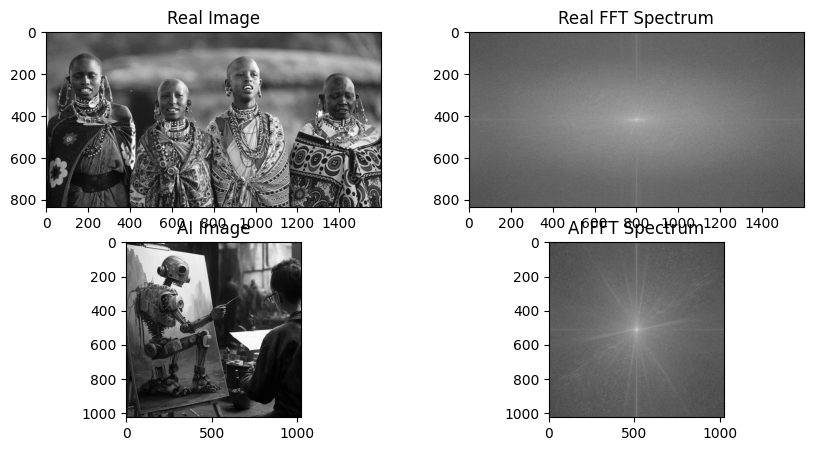

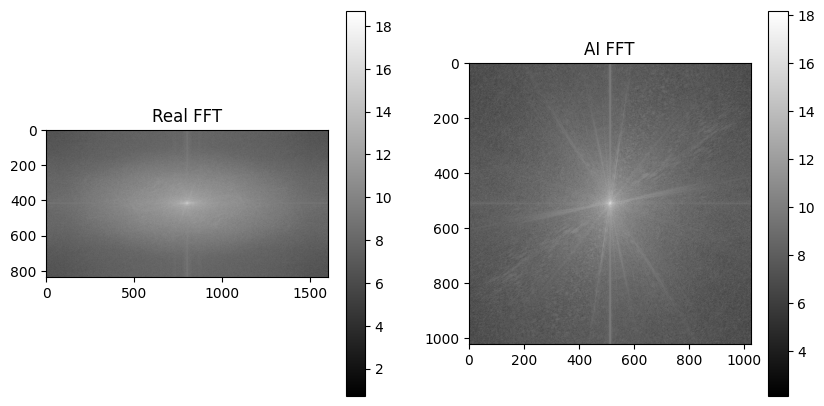

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

real = cv2.imread("RealArt/Women-clothing-Kenya-East-Africa.jpg",0)
ai = cv2.imread("AiArtData/Robt.png",0)
if real is None:
    print("Real image not loaded ")                         #Real Image - Higher Frequency , Ai -> lower and structured frequency 
if ai is None:
    print("AI image not loaded")

def compute_fft(image):
    f = np.fft.fft2(image)             
    fshift = np.fft.fftshift(f)        
    magnitude = np.log(1 + np.abs(fshift))  
    return fshift, magnitude

real_fft, real_mag = compute_fft(real)
ai_fft, ai_mag = compute_fft(ai)

print(real_mag)
print(ai_mag)
print("Real mean:", np.mean(real_mag))
print("AI mean:", np.mean(ai_mag))

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(real, cmap='gray')
plt.title("Real Image")

plt.subplot(2,2,2)
plt.imshow(real_mag, cmap='gray')
plt.title("Real FFT Spectrum")

plt.subplot(2,2,3)
plt.imshow(ai, cmap='gray')
plt.title("AI Image")

plt.subplot(2,2,4)
plt.imshow(ai_mag, cmap='gray')
plt.title("AI FFT Spectrum")

plt.show()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(real_mag, cmap='gray')
plt.colorbar()
plt.title("Real FFT")

plt.subplot(1,2,2)
plt.imshow(ai_mag, cmap='gray')
plt.colorbar()
plt.title("AI FFT")

plt.show()

Real Noise Variance: 14746.879041998776
AI Noise Variance: 13266.373031639996


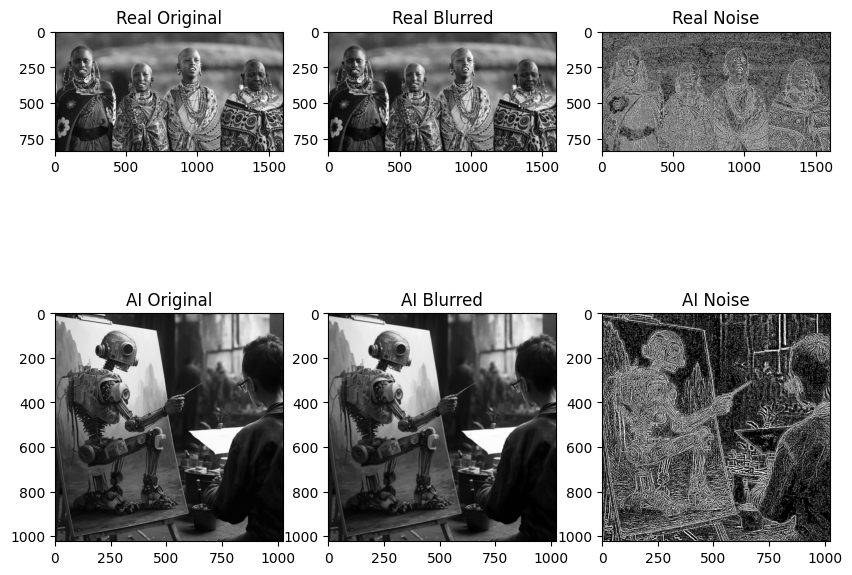

In [2]:
#NOISE PART ####Real image->Random noise with high variance, Ai -> Lower artificial noise
def get_noise(img):
    blur = cv2.GaussianBlur(img, (5,5), 0)
    noise = img - blur
    variance = np.var(noise)
    return blur, noise, variance

real_blur, real_noise, real_var = get_noise(real)
ai_blur, ai_noise, ai_var = get_noise(ai)

print("Real Noise Variance:", real_var)
print("AI Noise Variance:", ai_var)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

#for real
plt.subplot(2,3,1)
plt.imshow(real, cmap='gray')
plt.title("Real Original")

plt.subplot(2,3,2)
plt.imshow(real_blur, cmap='gray')
plt.title("Real Blurred")

plt.subplot(2,3,3)
plt.imshow(real_noise, cmap='gray')
plt.title("Real Noise")

# for ai 
plt.subplot(2,3,4)
plt.imshow(ai, cmap='gray')
plt.title("AI Original")

plt.subplot(2,3,5)
plt.imshow(ai_blur, cmap='gray')
plt.title("AI Blurred")

plt.subplot(2,3,6)
plt.imshow(ai_noise, cmap='gray')
plt.title("AI Noise")

plt.show()

Real Edge Density: 0.09941985645933014
AI Edge Density: 0.02936077117919922


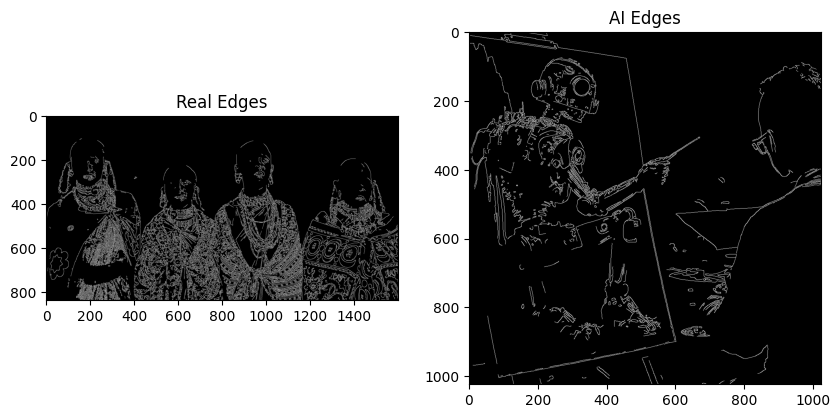

In [3]:
#edges in images   Real -> moderate and irregular edges , Ai-> can be low / high
import cv2
import numpy as np
import matplotlib.pyplot as plt

def edge_analysis(img):
    edges = cv2.Canny(img, 150, 250)
    edge_density = np.sum(edges > 0) / edges.size
    return edges, edge_density

real_edges, real_density = edge_analysis(real)
ai_edges, ai_density = edge_analysis(ai)

print("Real Edge Density:", real_density)
print("AI Edge Density:", ai_density)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(real_edges, cmap='gray')
plt.title("Real Edges")

plt.subplot(1,2,2)
plt.imshow(ai_edges, cmap='gray')
plt.title("AI Edges")

plt.show()

In [5]:
from skimage.feature import graycomatrix, graycoprops
import cv2

def glcm_features(img):
    # Convert to 8-bit (important)
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
    
    # Compute GLCM
    glcm = graycomatrix(
        img,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )
    
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    return contrast,homogeneity,correlation,energy,dissimilarity

# Apply on both images
real_contrast, real_homo, real_energy,real_corr,real_diss = glcm_features(real)
ai_contrast, ai_homo, ai_energy,ai_corr,ai_diss = glcm_features(ai)

print("REAL → Contrast:", real_contrast, "Homogeneity:", real_homo, "Energy:", real_energy,"real corr",real_corr,"real diss",real_diss)
print("AI   → Contrast:", ai_contrast, "Homogeneity:", ai_homo, "Energy:", ai_energy,"ai corr",ai_corr,"ai diss",ai_diss)

REAL → Contrast: 290.37541331154944 Homogeneity: 0.25541169652397405 Energy: 0.951266178681138 real corr 0.017031552732007578 real diss 9.119312758272965
AI   → Contrast: 86.72612242638074 Homogeneity: 0.45919957091580266 Energy: 0.9906777017610586 ai corr 0.03702877055786831 ai diss 3.6816663993768324


Real Color Variance: 2979.562844856384
AI Color Variance: 4528.6173719013705


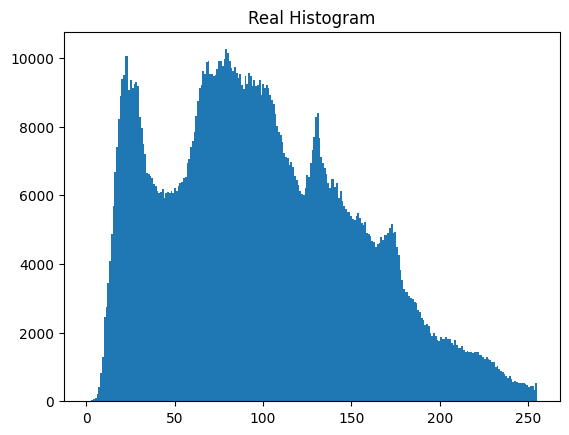

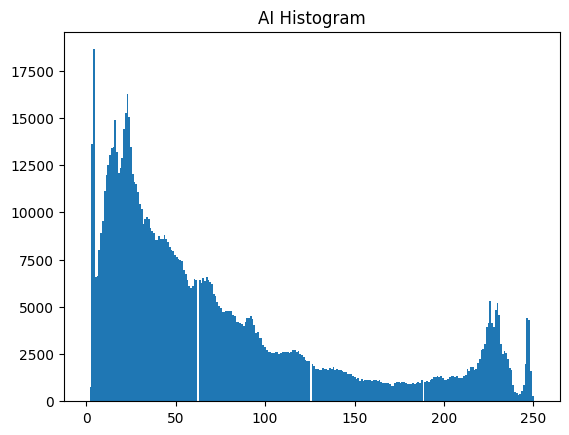

In [6]:
def color_variance(img): #---might not be useful
    return np.var(img)

real_color_var = color_variance(real)
ai_color_var = color_variance(ai)

print("Real Color Variance:", real_color_var)
print("AI Color Variance:", ai_color_var)

plt.hist(real.ravel(), bins=256)
plt.title("Real Histogram")
plt.show()

plt.hist(ai.ravel(), bins=256)
plt.title("AI Histogram")
plt.show()

In [10]:
def illumination_analysis(img): #might not be useful 
    # Extract illumination (low-frequency)
    illum = cv2.GaussianBlur(img, (31,31), 0)
    
    # Measure variation
    illum_var = np.var(illum)
    
    return illum, illum_var

real_illum, real_illum_var = illumination_analysis(real)
ai_illum, ai_illum_var = illumination_analysis(ai)

print("Real Illumination Variance:", real_illum_var)
print("AI Illumination Variance:", ai_illum_var)

Real Illumination Variance: 1974.4182620848962
AI Illumination Variance: 4043.3721474171457


In [14]:
from skimage.measure import shannon_entropy #might not be useful 

print("Real Entropy:", shannon_entropy(real))
print("AI Entropy:", shannon_entropy(ai))

Real Entropy: 7.6796975593969385
AI Entropy: 7.441685364073167


Real Laplacian Variance: 676.1036209463919
AI Laplacian Variance: 345.4673831329802


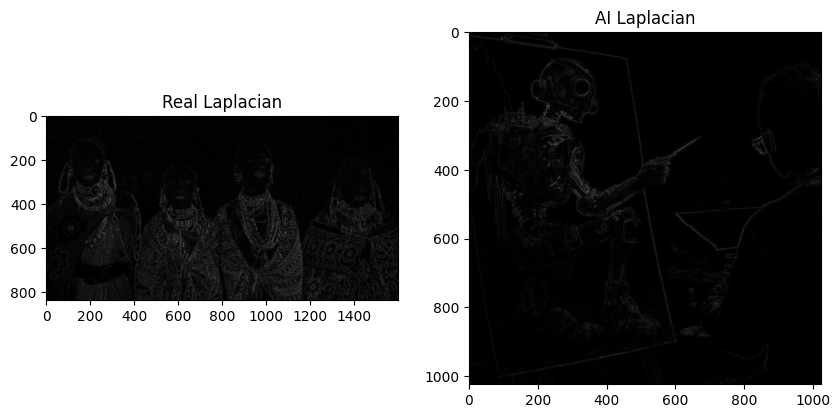

In [15]:
import cv2 #Laplacian Real -> More Variance , Ai-> Less variance 
import numpy as np
import matplotlib.pyplot as plt

def laplacian_analysis(img):
    # Apply Laplacian
    lap = cv2.Laplacian(img, cv2.CV_64F)
    
    # Compute variance (key feature)
    lap_var = np.var(lap)
    
    return lap, lap_var

# Apply to both images
real_lap, real_lap_var = laplacian_analysis(real)
ai_lap, ai_lap_var = laplacian_analysis(ai)


print("Real Laplacian Variance:", real_lap_var)
print("AI Laplacian Variance:", ai_lap_var)

real_lap = cv2.Laplacian(real, cv2.CV_64F)
ai_lap = cv2.Laplacian(ai, cv2.CV_64F)

# Take absolute
real_lap = np.abs(real_lap)
ai_lap = np.abs(ai_lap)

# Normalize to 0–255
real_lap = cv2.normalize(real_lap, None, 0, 255, cv2.NORM_MINMAX)
ai_lap = cv2.normalize(ai_lap, None, 0, 255, cv2.NORM_MINMAX)

# Convert to uint8
real_lap = real_lap.astype(np.uint8)
ai_lap = ai_lap.astype(np.uint8)


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(real_lap, cmap='gray')
plt.title("Real Laplacian")

plt.subplot(1,2,2)
plt.imshow(ai_lap, cmap='gray')
plt.title("AI Laplacian")

plt.show()